In [ ]:
from pathlib import Path
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 160)

DATA_PATH = Path("../data/raw/trialgpt/trialgpt_criterion_annotations.parquet")
assert DATA_PATH.exists(), f"File not found: {DATA_PATH.resolve()}"

df = pd.read_parquet(DATA_PATH)
df.head()

,annotation_id,patient_id,note,trial_id,trial_title,criterion_type,criterion_text,gpt4_explanation,explanation_correctness,gpt4_sentences,expert_sentences,gpt4_eligibility,expert_eligibility,training
0,0,sigir-20141,0. A 58-year-old African-American woman presents to the ER with episodic pressing/burning anterior chest pain that began two days earlier for the first time...,NCT01397994,Study to Assess Efficacy of Nicorandil+Atenolol vs Atenolol in Treatment of Chronic Stable Angina.,inclusion,Patients of chronic stable angina with abnormal Exercise Myocardial Perfusion Spect Scan with reversible and partially reversible ischemic changes.,The patient note does not provide direct evidence of the patient having chronic stable angina or having undergone an Exercise Myocardial Perfusion Spect Sca...,Correct,"[0, 1, 2]","[0, 1, 2]",not enough information,not enough information,True
1,1,sigir-20141,0. A 58-year-old African-American woman presents to the ER with episodic pressing/burning anterior chest pain that began two days earlier for the first time...,NCT01397994,Study to Assess Efficacy of Nicorandil+Atenolol vs Atenolol in Treatment of Chronic Stable Angina.,inclusion,Male and female,The patient is identified as a female in the note.,Correct,[0],[0],included,included,True
2,2,sigir-20141,0. A 58-year-old African-American woman presents to the ER with episodic pressing/burning anterior chest pain that began two days earlier for the first time...,NCT01397994,Study to Assess Efficacy of Nicorandil+Atenolol vs Atenolol in Treatment of Chronic Stable Angina.,inclusion,Age 25 to 65 years,"The patient is 58 years old, which falls within the specified age range.",Correct,[0],[0],included,included,True
3,3,sigir-20141,0. A 58-year-old African-American woman presents to the ER with episodic pressing/burning anterior chest pain that began two days earlier for the first time...,NCT01397994,Study to Assess Efficacy of Nicorandil+Atenolol vs Atenolol in Treatment of Chronic Stable Angina.,inclusion,"Patient must understand and be willing, able and likely to comply with all study procedures and restrictions and comprehends the diary cards.","The patient note mentions that the patient will comply with the trial protocol without any practical issues, which suggests that she understands and is will...",Correct,[8],[8],included,included,True
4,4,sigir-20141,0. A 58-year-old African-American woman presents to the ER with episodic pressing/burning anterior chest pain that began two days earlier for the first time...,NCT01397994,Study to Assess Efficacy of Nicorandil+Atenolol vs Atenolol in Treatment of Chronic Stable Angina.,inclusion,Patient must be able to give voluntary written informed consent.,The patient note mentions that the patient will provide informed consent.,Correct,[8],[8],included,included,True


In [2]:
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

Shape: 1,015 rows × 14 columns

Columns:
['annotation_id', 'patient_id', 'note', 'trial_id', 'trial_title', 'criterion_type', 'criterion_text', 'gpt4_explanation', 'explanation_correctness', 'gpt4_sentences', 'expert_sentences', 'gpt4_eligibility', 'expert_eligibility', 'training']

Data types:


,dtype
annotation_id,int64
patient_id,object
note,object
trial_id,object
trial_title,object
criterion_type,object
criterion_text,object
gpt4_explanation,object
explanation_correctness,object
gpt4_sentences,object


In [3]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   annotation_id            1015 non-null   int64 
 1   patient_id               1015 non-null   object
 2   note                     1015 non-null   object
 3   trial_id                 1015 non-null   object
 4   trial_title              1015 non-null   object
 5   criterion_type           1015 non-null   object
 6   criterion_text           1014 non-null   object
 7   gpt4_explanation         1015 non-null   object
 8   explanation_correctness  1015 non-null   object
 9   gpt4_sentences           1015 non-null   object
 10  expert_sentences         1015 non-null   object
 11  gpt4_eligibility         1015 non-null   object
 12  expert_eligibility       1015 non-null   object
 13  training                 1015 non-null   bool  
dtypes: bool(1), int64(1

In [4]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_%"] = (missing["missing_count"] / len(df) * 100).round(2)
display(missing.sort_values(["missing_count", "missing_%"], ascending=False))

,missing_count,missing_%
criterion_text,1,0.1
annotation_id,0,0.0
patient_id,0,0.0
note,0,0.0
trial_id,0,0.0
trial_title,0,0.0
criterion_type,0,0.0
gpt4_explanation,0,0.0
explanation_correctness,0,0.0
gpt4_sentences,0,0.0


In [5]:
print(f"Exact duplicate rows: {df.duplicated().sum():,}")

summary = pd.DataFrame({
    "non_null": df.notna().sum(),
    "unique_values": df.nunique(dropna=True),
    "example_value": [df[col].dropna().iloc[0] if df[col].notna().any() else None for col in df.columns]
})
display(summary)

Exact duplicate rows: 0


,non_null,unique_values,example_value
annotation_id,1015,1015,0
patient_id,1015,53,sigir-20141
note,1015,53,0. A 58-year-old African-American woman presents to the ER with episodic pressing/burning anterior chest pain that began two days earlier for the first time...
trial_id,1015,103,NCT01397994
trial_title,1015,103,Study to Assess Efficacy of Nicorandil+Atenolol vs Atenolol in Treatment of Chronic Stable Angina.
criterion_type,1015,2,inclusion
criterion_text,1014,1001,Patients of chronic stable angina with abnormal Exercise Myocardial Perfusion Spect Scan with reversible and partially reversible ischemic changes.
gpt4_explanation,1015,982,The patient note does not provide direct evidence of the patient having chronic stable angina or having undergone an Exercise Myocardial Perfusion Spect Sca...
explanation_correctness,1015,3,Correct
gpt4_sentences,1015,47,"[0, 1, 2]"


In [6]:
text_columns = df.select_dtypes(include="object").columns.tolist()

for col in text_columns:
    print(f"\n{'=' * 70}\n{col} — {df[col].nunique(dropna=True):,} unique non-null values")
    display(df[col].value_counts(dropna=False).head(15).to_frame("count"))


patient_id — 53 unique non-null values


,count
patient_id,
sigir-20144,43
sigir-201513,42
sigir-201415,39
sigir-201421,34
sigir-201524,32
sigir-20141,31
sigir-201416,30
sigir-201522,29
sigir-201430,29



note — 53 unique non-null values


,count
note,
"0. A 2-year-old boy is brought to the emergency department by his parents for 5 days of high fever and irritability.\n1. The physical exam reveals conjunctivitis, strawberry tongue, inflammation of the hands and feet, desquamation of the skin of the fingers and toes, and cervical lymphadenopathy with the smallest node at 1.5 cm.\n2. The abdominal exam demonstrates tenderness and enlarged liver.\n3. Laboratory tests report elevated alanine aminotransferase, white blood cell count of 17,580/mm, albumin 2.1 g/dL, C-reactive protein 4.5 mg, erythrocyte sedimentation rate 60 mm/h, mild normochromic, normocytic anemia, and leukocytes in urine of 20/mL with no bacteria identified.\n4. The echocardiogram shows moderate dilation of the coronary arteries with possible coronary artery aneurysm.\n5. The patient will provide informed consent, and will comply with the trial protocol without any practical issues.",43
"0. A 5-year-old boy presents to the emergency department with complaints of progressively worsening dysphagia, drooling, fever and vocal changes.\n1. He is toxic-appearing, and leans forward while sitting on his mother's lap.\n2. He is drooling and speaks with a muffled ""hot potato"" voice.\n3. The parents deny the possibility of foreign body ingestion or trauma, and they report that they are delaying some of his vaccines.\n4. The patient will provide informed consent, and will comply with the trial protocol without any practical issues.",42
"0. A 36-year-old woman presents to the emergency department with 12 weeks of amenorrhea, vaginal spotting that has increased since yesterday, lower abdominal tenderness, nausea and vomiting.\n1. The physical exam reveals overall tender abdomen, 18-week sized uterus, and cervical dilation of 2 cm.\n2. The complete blood count and biochemical profile are normal.\n3. Point of care pregnancy test with cut-off sensitivity of 25 mIU/ml Beta-HCG is negative.\n4. The ultrasound reports enlarged uterus (12 cm x 9 cm x 7 cms) with multiple cystic areas in the interior.\n5. The differential diagnosis includes vesicular mole vs fibroid degeneration.\n6. The patient will provide informed consent, and will comply with the trial protocol without any practical issues.",39
"0. A 21-year-old female is evaluated for progressive arthralgias and malaise.\n1. On examination she is found to have alopecia, a rash mainly distributed on the bridge of her nose and her cheeks, a delicate non-palpable purpura on her calves, and swelling and tenderness of her wrists and ankles.\n2. Her lab shows normocytic anemia, thrombocytopenia, a 4/4 positive ANA and anti-dsDNA.\n3. Her urine is positive for protein and RBC casts.\n4. The patient will provide informed consent, and will comply with the trial protocol without any practical issues.",34
"0. A 31 yo male with no significant past medical history presents with productive cough and chest pain.\n1. He reports developing cold symptoms one week ago that were improving until two days ago, when he developed a new fever, chills, and worsening cough.\n2. He has right-sided chest pain that is aggravated by coughing.\n3. His wife also had cold symptoms a week ago but is now feeling well.\n4. Vitals signs include temperature 103.4, pulse 105, blood pressure 120/80, and respiratory rate 15.\n5. Lung exam reveals expiratory wheezing, decreased breath sounds, and egophany in the left lower lung field.\n6. The patient will provide informed consent, and will comply with the trial protocol without any practical issues.",32
"0. A 58-year-old African-American woman presents to the ER with episodic pressing/burning anterior chest pain that began two days earlier for the first time in her life.\n1. The pain started while she was walking, radiates to the back, and is accompanied by nausea, diaphoresis and mild dyspnea, but is not increased on inspiration.\n2. The latest episode of pain ended half an hour prior to her arrival.\n3. She is known to have hypertension and obesity.\n4


trial_id — 103 unique non-null values


...

,count
expert_sentences,
[],610
[0],127
[3],37
[4],35
[5],27
[1],27
[6],18
[2],16
"[0, 3]",11



gpt4_eligibility — 6 unique non-null values


,count
gpt4_eligibility,
not excluded,426
not enough information,289
included,139
not applicable,119
not included,26
excluded,16



expert_eligibility — 6 unique non-null values


,count
expert_eligibility,
not excluded,484
not enough information,293
included,150
not applicable,55
not included,23
excluded,10


In [7]:
print("Random sample:")
display(df.sample(min(5, len(df)), random_state=42))

Random sample:


,annotation_id,patient_id,note,trial_id,trial_title,criterion_type,criterion_text,gpt4_explanation,explanation_correctness,gpt4_sentences,expert_sentences,gpt4_eligibility,expert_eligibility,training
752,752,sigir-201513,"0. A 5-year-old boy presents to the emergency department with complaints of progressively worsening dysphagia, drooling, fever and vocal changes.\n1. He is ...",NCT01255670,Penicillin and Metronidazole in Treatment of Peritonsillar Abscess,exclusion,renal insufficiency,"The patient note does not mention any kidney problems, so there is no direct evidence. However, renal insufficiency is a significant medical condition that ...",Correct,[],[],not excluded,not excluded,True
519,519,sigir-201429,0. A 51-year-old woman is seen in clinic for advice on osteoporosis.\n1. She has a past medical history of significant hypertension and diet-controlled diab...,NCT01978834,Age Dependend Diagnostic Thresholds for Osteoporosis Bindex Ultrasonometer,inclusion,Female sex,"The patient is a woman, which is directly stated in the note. Therefore, she meets this criterion.",Correct,[0],[0],included,included,True
210,210,sigir-201413,0. A 30-year-old generally healthy woman presents with shortness of breath that had started 2 hours before admission.\n1. She has had no health problems in ...,NCT02264769,Carbetocin at Elective Cesarean Delivery Part 4,inclusion,Written informed consent to participate in this study,"The patient note directly states that 'The patient will provide informed consent, and will comply with the trial protocol without any practical issues.' The...",Correct,[6],[6],included,included,True
611,611,sigir-20152,"0. A 62 yo male presents with four days of non-productive cough and one day of fever.\n1. He is on immunosuppressive medications, including prednisone.\n2. ...",NCT00034437,Immune Response to Cytomegalovirus,inclusion,Informed consent given,The patient note directly mentions that the patient will provide informed consent and will comply with the trial protocol without any practical issues.,Correct,[4],[4],included,included,True
914,914,sigir-201521,"0. A 32-year-old male presents to your office complaining of diarrhea, abdominal cramping and flatulence.\n1. Stools are greasy and foul-smelling.\n2. He al...",NCT02105714,Diagnosis of Neglected Tropical Diseases Among Patients With Persistent Digestive Disorders,exclusion,"Individuals who are unable, in the study physician's opinion, to comply with the study requirements.",The patient note directly states that the patient will comply with the trial protocol without any practical issues.,Correct,[5],[5],not excluded,not excluded,True


inspect the exact source labels, split, and patient coverage

In [8]:
for col in ["criterion_type", "expert_eligibility", "gpt4_eligibility", "explanation_correctness", "training"]:
    print(f"\n{col}")
    display(df[col].value_counts(dropna=False).to_frame("count"))


criterion_type


,count
criterion_type,
exclusion,659
inclusion,356



expert_eligibility


,count
expert_eligibility,
not excluded,484
not enough information,293
included,150
not applicable,55
not included,23
excluded,10



gpt4_eligibility


,count
gpt4_eligibility,
not excluded,426
not enough information,289
included,139
not applicable,119
not included,26
excluded,16



explanation_correctness


,count
explanation_correctness,
Correct,891
Partially Correct,98
Incorrect,26



training


,count
training,
True,881
False,134


In [10]:
print("Expert label by criterion type:")
display(pd.crosstab(df["criterion_type"], df["expert_eligibility"], margins=True))

print("\nTrain/test split:")
display(pd.crosstab(df["training"], df["expert_eligibility"], margins=True))

Expert label by criterion type:


expert_eligibility,excluded,included,not applicable,not enough information,not excluded,not included,All
criterion_type,,,,,,,
exclusion,10,0,46,119,484,0,659
inclusion,0,150,9,174,0,23,356
All,10,150,55,293,484,23,1015



Train/test split:


expert_eligibility,excluded,included,not applicable,not enough information,not excluded,not included,All
training,,,,,,,
False,0,15,2,41,70,6,134
True,10,135,53,252,414,17,881
All,10,150,55,293,484,23,1015


whether each patient has enough annotations for a useful 30-patient cohort

In [11]:
patient_summary = df.groupby("patient_id").agg(
    criteria=("annotation_id", "size"),
    trials=("trial_id", "nunique"),
    labels=("expert_eligibility", lambda x: ", ".join(sorted(x.dropna().unique()))),
    split=("training", lambda x: ", ".join(map(str, sorted(x.unique()))))
).sort_values("criteria", ascending=False)

display(patient_summary)

,criteria,trials,labels,split
patient_id,,,,
sigir-20144,43,2,"included, not applicable, not enough information, not excluded","False, True"
sigir-201513,42,2,"included, not applicable, not enough information, not excluded",True
sigir-201415,39,2,"excluded, included, not enough information, not excluded","False, True"
sigir-201421,34,2,"included, not enough information, not excluded","False, True"
sigir-201524,32,2,"included, not applicable, not enough information, not excluded","False, True"
sigir-20141,31,2,"included, not applicable, not enough information, not excluded","False, True"
sigir-201416,30,2,"excluded, included, not enough information, not excluded, not included",True
sigir-20151,29,2,"included, not applicable, not enough information, not excluded","False, True"
sigir-201430,29,2,"included, not applicable, not enough information, not excluded","False, True"


In [12]:
label_map = {
    ("inclusion", "included"): "MET",
    ("inclusion", "not included"): "NOT_MET",
    ("exclusion", "not excluded"): "MET",
    ("exclusion", "excluded"): "NOT_MET",
    ("inclusion", "not enough information"): "UNKNOWN",
    ("exclusion", "not enough information"): "UNKNOWN",
    ("inclusion", "not applicable"): "NOT_APPLICABLE",
    ("exclusion", "not applicable"): "NOT_APPLICABLE"
}

working_df = df.copy()
working_df["ground_truth_label"] = working_df.apply(
    lambda row: label_map.get((row["criterion_type"], row["expert_eligibility"])), axis=1
)

assert working_df["ground_truth_label"].notna().all(), "Unmapped labels found"
display(pd.crosstab(working_df["criterion_type"], working_df["ground_truth_label"], margins=True))

ground_truth_label,MET,NOT_APPLICABLE,NOT_MET,UNKNOWN,All
criterion_type,,,,,
exclusion,484,46,10,119,659
inclusion,150,9,23,174,356
All,634,55,33,293,1015


whether all 53 patients can be used and how labels are distributed per patient

In [13]:
patient_labels = working_df.pivot_table(
    index="patient_id",
    columns="ground_truth_label",
    values="annotation_id",
    aggfunc="count",
    fill_value=0
)

patient_labels["total_assessments"] = patient_labels.sum(axis=1)
display(patient_labels.sort_values("total_assessments", ascending=False))

ground_truth_label,MET,NOT_APPLICABLE,NOT_MET,UNKNOWN,total_assessments
patient_id,,,,,
sigir-20144,37,2,0,4,43
sigir-201513,23,7,0,12,42
sigir-201415,24,0,1,14,39
sigir-201421,14,0,0,20,34
sigir-201524,25,2,0,5,32
sigir-20141,24,1,0,6,31
sigir-201416,23,0,2,5,30
sigir-20151,15,1,0,13,29
sigir-201430,14,3,0,12,29


In [14]:
patient_pool = patient_labels.reset_index()
risk_patients = patient_pool[patient_pool["NOT_MET"] > 0].sort_values(
    ["NOT_MET", "UNKNOWN", "total_assessments"], ascending=False
).head(15)

remaining_patients = patient_pool[~patient_pool["patient_id"].isin(risk_patients["patient_id"])].sort_values(
    ["UNKNOWN", "NOT_APPLICABLE", "total_assessments"], ascending=False
).head(15)

selected_patient_ids = pd.concat([risk_patients, remaining_patients])["patient_id"].tolist()
assert len(selected_patient_ids) == 30
assert len(set(selected_patient_ids)) == 30

cohort_df = working_df[working_df["patient_id"].isin(selected_patient_ids)].copy()

print(f"Selected patients: {cohort_df['patient_id'].nunique()}")
print(f"Selected assessments: {len(cohort_df)}")
display(cohort_df["ground_truth_label"].value_counts().to_frame("count"))
display(cohort_df[["patient_id", "trial_id", "trial_title"]].drop_duplicates().sort_values(["patient_id", "trial_id"]))

Selected patients: 30
Selected assessments: 700


,count
ground_truth_label,
MET,411
UNKNOWN,219
NOT_APPLICABLE,42
NOT_MET,28


,patient_id,trial_id,trial_title
21,sigir-20141,NCT00149227,Add-on Effects of Valsartan on Morbi- Mortality (KYOTO HEART Study)
0,sigir-20141,NCT01397994,Study to Assess Efficacy of Nicorandil+Atenolol vs Atenolol in Treatment of Chronic Stable Angina.
159,sigir-201410,NCT02097186,Preconditioning Shields Against Vascular Events in Surgery
175,sigir-201410,NCT02264964,Duration and Adverse Events of Non-cuffed Catheter in Patients With Hemodialysis
216,sigir-201413,NCT00163709,BNP Testing in Patients With SOB on Presentation to ED
209,sigir-201413,NCT02264769,Carbetocin at Elective Cesarean Delivery Part 4
243,sigir-201415,NCT00180739,Safety Trial of Magnetic Resonance (MR) Guided Focused Ultrasound Surgery (FUS) in Women With Uterine Fibroids Wishing to Pursue Pregnancy in the Future
235,sigir-201415,NCT00277680,Laparoscopic Occlusion of Uterine Vessels Compared to Uterine Fibroid Embolization for Treatment of Uterine Fibroids
274,sigir-201416,NCT02238756,Safety and Tolerability of CV8102 Alone and in Combination With a Rabies Virus Vaccine in Healthy Adults
295,sigir-201416,NCT02374814,Immunogenicity of Rabies Vaccine for Pre Exposure Prophylaxis


select exactly four rows per patient: 30 patients × 4 criterion assessments = 120 rows.

Within each patient, the selection prioritises the most safety-relevant labels:

NOT_MET
UNKNOWN
NOT_APPLICABLE
MET

That guarantees every patient is represented while deliberately retaining rare and important outcomes when they exist.

In [15]:
label_priority = {"NOT_MET": 0, "UNKNOWN": 1, "NOT_APPLICABLE": 2, "MET": 3}

cohort_clean = cohort_df.dropna(subset=["criterion_text"]).copy()
cohort_clean["label_priority"] = cohort_clean["ground_truth_label"].map(label_priority)

evaluation_df = cohort_clean.sort_values(
    ["patient_id", "label_priority", "annotation_id"]
).groupby("patient_id", group_keys=False).head(4).copy()

assert evaluation_df["patient_id"].nunique() == 30
assert len(evaluation_df) == 120

print(f"Patients: {evaluation_df['patient_id'].nunique()}")
print(f"Patient–trial–criterion assessments: {len(evaluation_df)}")

print("\nLabel distribution:")
display(evaluation_df["ground_truth_label"].value_counts().reindex(label_priority).fillna(0).astype(int).to_frame("count"))

print("\nCriterion-type distribution:")
display(evaluation_df["criterion_type"].value_counts().to_frame("count"))

print("\nTrial contexts:")
print(evaluation_df[["patient_id", "trial_id"]].drop_duplicates().shape[0])
display(evaluation_df[["patient_id", "trial_id", "trial_title"]].drop_duplicates().sort_values(["patient_id", "trial_id"]))

Patients: 30
Patient–trial–criterion assessments: 120

Label distribution:


,count
ground_truth_label,
NOT_MET,27
UNKNOWN,92
NOT_APPLICABLE,0
MET,1



Criterion-type distribution:


,count
criterion_type,
inclusion,84
exclusion,36



Trial contexts:
44


,patient_id,trial_id,trial_title
0,sigir-20141,NCT01397994,Study to Assess Efficacy of Nicorandil+Atenolol vs Atenolol in Treatment of Chronic Stable Angina.
161,sigir-201410,NCT02097186,Preconditioning Shields Against Vascular Events in Surgery
216,sigir-201413,NCT00163709,BNP Testing in Patients With SOB on Presentation to ED
209,sigir-201413,NCT02264769,Carbetocin at Elective Cesarean Delivery Part 4
263,sigir-201415,NCT00180739,Safety Trial of Magnetic Resonance (MR) Guided Focused Ultrasound Surgery (FUS) in Women With Uterine Fibroids Wishing to Pursue Pregnancy in the Future
235,sigir-201415,NCT00277680,Laparoscopic Occlusion of Uterine Vessels Compared to Uterine Fibroid Embolization for Treatment of Uterine Fibroids
284,sigir-201416,NCT02238756,Safety and Tolerability of CV8102 Alone and in Combination With a Rabies Virus Vaccine in Healthy Adults
298,sigir-201416,NCT02374814,Immunogenicity of Rabies Vaccine for Pre Exposure Prophylaxis
305,sigir-201417,NCT01745731,Cell Infusion Intraportal Autologous Bone Marrow Mononuclear as Enhancer of Liver Regeneration
331,sigir-201418,NCT01260883,Ketorolac in Postoperative Infants: Pharmacokinetics and Safety


checks: label balance and inclusion/exclusion balance

In [16]:
display(evaluation_df["ground_truth_label"].value_counts().reindex(["MET", "NOT_MET", "UNKNOWN", "NOT_APPLICABLE"]).fillna(0).astype(int).to_frame("count"))
display(evaluation_df["criterion_type"].value_counts().to_frame("count"))

,count
ground_truth_label,
MET,1
NOT_MET,27
UNKNOWN,92
NOT_APPLICABLE,0


,count
criterion_type,
inclusion,84
exclusion,36


In [17]:
slot_preferences = [
    ["MET", "UNKNOWN", "NOT_MET", "NOT_APPLICABLE"],
    ["UNKNOWN", "MET", "NOT_MET", "NOT_APPLICABLE"],
    ["NOT_MET", "UNKNOWN", "MET", "NOT_APPLICABLE"],
    ["NOT_APPLICABLE", "UNKNOWN", "MET", "NOT_MET"]
]

selected_rows = []

for patient_id, patient_rows in cohort_clean.groupby("patient_id", sort=True):
    used_indices = set()
    for preferences in slot_preferences:
        available = patient_rows.loc[~patient_rows.index.isin(used_indices)].copy()
        priority = {label: i for i, label in enumerate(preferences)}
        available["selection_priority"] = available["ground_truth_label"].map(priority)
        chosen = available.sort_values(["selection_priority", "annotation_id"]).iloc[0]
        selected_rows.append(chosen.drop(labels="selection_priority"))
        used_indices.add(chosen.name)

evaluation_df = pd.DataFrame(selected_rows).reset_index(drop=True)

assert evaluation_df["patient_id"].nunique() == 30
assert len(evaluation_df) == 120

display(evaluation_df["ground_truth_label"].value_counts().reindex(
    ["MET", "NOT_MET", "UNKNOWN", "NOT_APPLICABLE"]
).fillna(0).astype(int).to_frame("count"))

display(evaluation_df["criterion_type"].value_counts().to_frame("count"))

,count
ground_truth_label,
MET,32
NOT_MET,17
UNKNOWN,52
NOT_APPLICABLE,19


,count
criterion_type,
inclusion,79
exclusion,41


| Label            | Rows | Meaning                                                         |
| ---------------- | ---: | --------------------------------------------------------------- |
| `MET`            |   32 | Clear supporting evidence                                       |
| `NOT_MET`        |   17 | Important negative cases for unsafe false-positive testing      |
| `UNKNOWN`        |   52 | Tests whether the model correctly abstains rather than guessing |
| `NOT_APPLICABLE` |   19 | Tests correct handling of non-applicable criteria               |


In [19]:
sample_records = evaluation_df.groupby("ground_truth_label", group_keys=False).sample(n=2, random_state=42)

display(sample_records[[
    "patient_id", "trial_id", "criterion_type", "criterion_text",
    "ground_truth_label", "note", "expert_sentences", "gpt4_eligibility"
]].sort_values(["ground_truth_label", "patient_id"]))

,patient_id,trial_id,criterion_type,criterion_text,ground_truth_label,note,expert_sentences,gpt4_eligibility
52,sigir-201430,NCT02273232,exclusion,Known upper limb PVD,MET,0. A 72-year-old man complains of increasing calf pain when walking uphill.\n1. The symptoms have gradually increased over the past 3 months.\n2. The patien...,[],not excluded
108,sigir-201524,NCT00711399,inclusion,Patient and/or parents/guardian signed informed consent,MET,0. A 31 yo male with no significant past medical history presents with productive cough and chest pain.\n1. He reports developing cold symptoms one week ago...,[6],included
7,sigir-201410,NCT02097186,exclusion,Pregnancy,NOT_APPLICABLE,0. A physician is called to see a 67-year-old woman who underwent cardiac catheterization via the right femoral artery earlier in the morning.\n1. She is no...,[],not applicable
119,sigir-20158,NCT02562040,exclusion,"Previous tonsillectomy, including partial tonsillectomy",NOT_APPLICABLE,"0. A 10 yo boy with nighttime snoring, pauses in breathing, and restlessness with nighttime awakenings.\n1. No history of headache or night terrors.\n2. The...",[],not applicable
46,sigir-201426,NCT00373048,exclusion,Intent to move out of the study catchment area during the study period,NOT_MET,0. A group of 14 humanitarian service workers is preparing a trip to the Amazon Rainforest region in Brazil.\n1. All the members of the group have traveled ...,[0],excluded
62,sigir-20147,NCT01863628,exclusion,DSM-IV defined Axis I disorders,NOT_MET,0. A 26-year-old obese woman with a history of bipolar disorder complains that her recent struggles with her weight and eating have caused her to feel depre...,[0],excluded
15,sigir-201415,NCT00180739,inclusion,"1. Subject with uterine fibroids, who desire pregnancy within 12 months and has the one of the following criteria: Women 20-40 age. Women age < 46 years old...",UNKNOWN,"0. A 36-year-old woman presents to the emergency department with 12 weeks of amenorrhea, vaginal spotting that has increased since yesterday, lower abdomina...","[0, 3, 5]",not enough information
101,sigir-201522,NCT02534727,inclusion,Suspected drug resistance (drug susceptible allowed at the NIH CC),UNKNOWN,0. A 65-year-old male with a history of tuberculosis has started to complain of productive cough with tinges of blood.\n1. Chest X-ray reveals a round opaqu...,[0],not enough information


The source gpt4_eligibility is only the published TrialGPT baseline output. We will preserve it for comparison, but your own model runs will create new predictions later

### create the three clean project tables from the locked 120-row evaluation set

In [20]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

patients_df = evaluation_df[["patient_id", "note"]].drop_duplicates("patient_id").rename(columns={"note": "patient_summary"})
criteria_df = evaluation_df[["trial_id", "trial_title", "criterion_type", "criterion_text"]].drop_duplicates().reset_index(drop=True)
criteria_df.insert(0, "criterion_id", [f"CRIT_{i:03d}" for i in range(1, len(criteria_df) + 1)])

ground_truth_df = evaluation_df.merge(
    criteria_df, on=["trial_id", "trial_title", "criterion_type", "criterion_text"], how="left"
)[[
    "annotation_id", "patient_id", "trial_id", "criterion_id", "criterion_type",
    "ground_truth_label", "expert_eligibility", "expert_sentences",
    "gpt4_eligibility", "gpt4_explanation", "explanation_correctness", "training"
]].rename(columns={"annotation_id": "source_annotation_id", "expert_sentences": "expert_evidence_sentence_ids"})

assert len(patients_df) == 30
assert len(ground_truth_df) == 120
assert ground_truth_df["criterion_id"].notna().all()

display(patients_df.head(3))
display(criteria_df.head(3))
display(ground_truth_df.head(3))

,patient_id,patient_summary
0,sigir-20141,0. A 58-year-old African-American woman presents to the ER with episodic pressing/burning anterior chest pain that began two days earlier for the first time...
4,sigir-201410,0. A physician is called to see a 67-year-old woman who underwent cardiac catheterization via the right femoral artery earlier in the morning.\n1. She is no...
8,sigir-201413,0. A 30-year-old generally healthy woman presents with shortness of breath that had started 2 hours before admission.\n1. She has had no health problems in ...


,criterion_id,trial_id,trial_title,criterion_type,criterion_text
0,CRIT_001,NCT01397994,Study to Assess Efficacy of Nicorandil+Atenolol vs Atenolol in Treatment of Chronic Stable Angina.,inclusion,Male and female
1,CRIT_002,NCT01397994,Study to Assess Efficacy of Nicorandil+Atenolol vs Atenolol in Treatment of Chronic Stable Angina.,inclusion,Patients of chronic stable angina with abnormal Exercise Myocardial Perfusion Spect Scan with reversible and partially reversible ischemic changes.
2,CRIT_003,NCT01397994,Study to Assess Efficacy of Nicorandil+Atenolol vs Atenolol in Treatment of Chronic Stable Angina.,exclusion,Unstable angina


,source_annotation_id,patient_id,trial_id,criterion_id,criterion_type,ground_truth_label,expert_eligibility,expert_evidence_sentence_ids,gpt4_eligibility,gpt4_explanation,explanation_correctness,training
0,1,sigir-20141,NCT01397994,CRIT_001,inclusion,MET,included,[0],included,The patient is identified as a female in the note.,Correct,True
1,0,sigir-20141,NCT01397994,CRIT_002,inclusion,UNKNOWN,not enough information,"[0, 1, 2]",not enough information,The patient note does not provide direct evidence of the patient having chronic stable angina or having undergone an Exercise Myocardial Perfusion Spect Sca...,Correct,True
2,8,sigir-20141,NCT01397994,CRIT_003,exclusion,UNKNOWN,not enough information,"[0, 1, 2]",not enough information,"The patient presents with episodic chest pain, which could be a symptom of unstable angina. However, the note does not specify whether the angina is stable ...",Correct,True


| Table             | Contains                                                                                      | Why it exists                                                                                    |
| ----------------- | --------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------ |
| `patients_df`     | One row per synthetic patient: ID and clinical summary                                        | The patient record sent to the LLM. It prevents repeating the same note in every assessment row. |
| `criteria_df`     | One row per selected eligibility criterion: trial, title, inclusion/exclusion type and text   | The trial-protocol input sent to the LLM. Each `criterion_id` is a stable reference.             |
| `ground_truth_df` | One row per patient × trial × criterion assessment: reference label and evidence sentence IDs | The evaluation answer key. It lets us compare your model’s prediction with the expert label.     |


In [21]:
print("patients_df")
display(patients_df.head(3))

print("criteria_df")
display(criteria_df.head(3))

print("ground_truth_df")
display(ground_truth_df.head(3))

patients_df


,patient_id,patient_summary
0,sigir-20141,0. A 58-year-old African-American woman presents to the ER with episodic pressing/burning anterior chest pain that began two days earlier for the first time...
4,sigir-201410,0. A physician is called to see a 67-year-old woman who underwent cardiac catheterization via the right femoral artery earlier in the morning.\n1. She is no...
8,sigir-201413,0. A 30-year-old generally healthy woman presents with shortness of breath that had started 2 hours before admission.\n1. She has had no health problems in ...


criteria_df


,criterion_id,trial_id,trial_title,criterion_type,criterion_text
0,CRIT_001,NCT01397994,Study to Assess Efficacy of Nicorandil+Atenolol vs Atenolol in Treatment of Chronic Stable Angina.,inclusion,Male and female
1,CRIT_002,NCT01397994,Study to Assess Efficacy of Nicorandil+Atenolol vs Atenolol in Treatment of Chronic Stable Angina.,inclusion,Patients of chronic stable angina with abnormal Exercise Myocardial Perfusion Spect Scan with reversible and partially reversible ischemic changes.
2,CRIT_003,NCT01397994,Study to Assess Efficacy of Nicorandil+Atenolol vs Atenolol in Treatment of Chronic Stable Angina.,exclusion,Unstable angina


ground_truth_df


,source_annotation_id,patient_id,trial_id,criterion_id,criterion_type,ground_truth_label,expert_eligibility,expert_evidence_sentence_ids,gpt4_eligibility,gpt4_explanation,explanation_correctness,training
0,1,sigir-20141,NCT01397994,CRIT_001,inclusion,MET,included,[0],included,The patient is identified as a female in the note.,Correct,True
1,0,sigir-20141,NCT01397994,CRIT_002,inclusion,UNKNOWN,not enough information,"[0, 1, 2]",not enough information,The patient note does not provide direct evidence of the patient having chronic stable angina or having undergone an Exercise Myocardial Perfusion Spect Sca...,Correct,True
2,8,sigir-20141,NCT01397994,CRIT_003,exclusion,UNKNOWN,not enough information,"[0, 1, 2]",not enough information,"The patient presents with episodic chest pain, which could be a symptom of unstable angina. However, the note does not specify whether the angina is stable ...",Correct,True


#### export the verified clean tables as CSVs

In [22]:
patients_df.to_csv(processed_dir / "patients.csv", index=False)
criteria_df.to_csv(processed_dir / "trial_criteria.csv", index=False)
ground_truth_df.to_csv(processed_dir / "ground_truth.csv", index=False)

for file_name in ["patients.csv", "trial_criteria.csv", "ground_truth.csv"]:
    path = processed_dir / file_name
    print(f"{file_name}: {pd.read_csv(path).shape} | {path.resolve()}")

patients.csv: (30, 2) | /Users/nevena/Ironhack_Labs/week9/Clinical-trial-eligibility-copilot/data/processed/patients.csv
trial_criteria.csv: (120, 5) | /Users/nevena/Ironhack_Labs/week9/Clinical-trial-eligibility-copilot/data/processed/trial_criteria.csv
ground_truth.csv: (120, 12) | /Users/nevena/Ironhack_Labs/week9/Clinical-trial-eligibility-copilot/data/processed/ground_truth.csv


In [23]:
allowed_labels = {"MET", "NOT_MET", "UNKNOWN", "NOT_APPLICABLE"}
allowed_types = {"inclusion", "exclusion"}

checks = {
    "30 unique patients": patients_df["patient_id"].nunique() == 30,
    "patient IDs unique": patients_df["patient_id"].is_unique,
    "patient summaries complete": patients_df["patient_summary"].notna().all() and patients_df["patient_summary"].str.strip().ne("").all(),
    "criterion IDs unique": criteria_df["criterion_id"].is_unique,
    "criterion text complete": criteria_df["criterion_text"].notna().all() and criteria_df["criterion_text"].str.strip().ne("").all(),
    "120 assessments": len(ground_truth_df) == 120,
    "source annotation IDs unique": ground_truth_df["source_annotation_id"].is_unique,
    "valid ground-truth labels": ground_truth_df["ground_truth_label"].isin(allowed_labels).all(),
    "valid criterion types": ground_truth_df["criterion_type"].isin(allowed_types).all(),
    "all assessment patients exist": ground_truth_df["patient_id"].isin(patients_df["patient_id"]).all(),
    "all assessment criteria exist": ground_truth_df["criterion_id"].isin(criteria_df["criterion_id"]).all(),
    "four assessments per patient": ground_truth_df.groupby("patient_id").size().eq(4).all()
}

validation_results = pd.Series(checks, name="passed").to_frame()
display(validation_results)

assert validation_results["passed"].all(), "At least one validation check failed"
print("All dataset validation checks passed.")

,passed
30 unique patients,True
patient IDs unique,True
patient summaries complete,True
criterion IDs unique,True
criterion text complete,True
120 assessments,True
source annotation IDs unique,True
valid ground-truth labels,True
valid criterion types,True
all assessment patients exist,True


All dataset validation checks passed.


| Metric                                   | What it measures                                                   | Question it answers                                                            | Why it matters                                                                           |
| ---------------------------------------- | ------------------------------------------------------------------ | ------------------------------------------------------------------------------ | ---------------------------------------------------------------------------------------- |
| **1. Assessments processed**             | Number of patient × trial × criterion assessments evaluated        | “How much screening work does this result cover?”                              | Gives context for every percentage and shows workflow volume.                            |
| **2. Review / clarification rate**       | Share of cases labelled `UNKNOWN` or `NOT_APPLICABLE`              | “How much work still needs clarification before formal screening?”             | Shows realistic coordinator workload; AI should surface uncertainty rather than hide it. |
| **3. Overall criterion-label agreement** | % of predicted labels equal to expert ground truth                 | “How often does the AI reach the same conclusion as the reference assessment?” | Main overall quality measure.                                                            |
| **4. Unsafe `MET` rate**                 | % of true `NOT_MET` cases predicted as `MET`                       | “How often could AI wrongly advance a patient who does not meet a criterion?”  | The most important safety measure. Lower is better.                                      |
| **5. `UNKNOWN` recall**                  | % of true `UNKNOWN` cases correctly predicted as `UNKNOWN`         | “Does the AI abstain when information is insufficient?”                        | Prevents confident guessing from incomplete notes.                                       |
| **6. Evidence-grounding pass rate**      | % of outputs whose cited evidence supports the label and rationale | “Can a coordinator verify why the AI reached its conclusion?”                  | Makes the output reviewable and auditable.                                               |
| **7. Estimated cost per assessment**     | Total model cost ÷ assessment count                                | “Is the approach economically realistic at the intended volume?”               | Supports the CRO’s build/buy/integrate decision.                                         |


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {"MET": "#2E8B57", "NOT_MET": "#D55E00", "UNKNOWN": "#E69F00", "NOT_APPLICABLE": "#7B61A8"}

### Cohort size and patient–trial context count

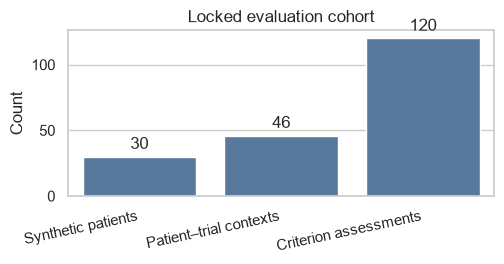

In [25]:
cohort_counts = pd.DataFrame({
    "metric": ["Synthetic patients", "Patient–trial contexts", "Criterion assessments"],
    "count": [
        evaluation_df["patient_id"].nunique(),
        evaluation_df[["patient_id", "trial_id"]].drop_duplicates().shape[0],
        len(evaluation_df)
    ]
})

fig, ax = plt.subplots(figsize=(5.2, 2.8))
sns.barplot(data=cohort_counts, x="metric", y="count", color="#4C78A8", ax=ax)
ax.bar_label(ax.containers[0], padding=3)
ax.set(xlabel="", ylabel="Count", title="Locked evaluation cohort")
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()

### Ground-truth label distribution

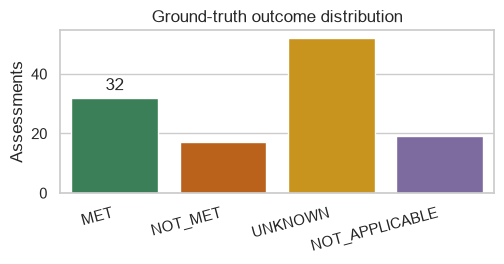

In [26]:
label_order = ["MET", "NOT_MET", "UNKNOWN", "NOT_APPLICABLE"]
label_counts = evaluation_df["ground_truth_label"].value_counts().reindex(label_order).reset_index()
label_counts.columns = ["ground_truth_label", "count"]

fig, ax = plt.subplots(figsize=(5.2, 2.8))
sns.barplot(data=label_counts, x="ground_truth_label", y="count", hue="ground_truth_label", palette=PALETTE, legend=False, ax=ax)
ax.bar_label(ax.containers[0], padding=3)
ax.set(xlabel="", ylabel="Assessments", title="Ground-truth outcome distribution")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Inclusion versus exclusion criterion mix

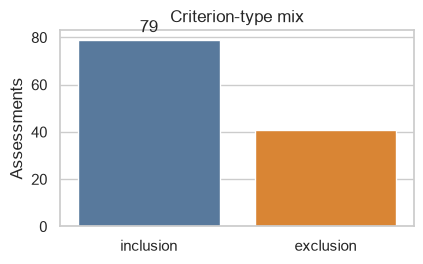

In [27]:
type_counts = evaluation_df["criterion_type"].value_counts().reset_index()
type_counts.columns = ["criterion_type", "count"]

fig, ax = plt.subplots(figsize=(4.4, 2.8))
sns.barplot(data=type_counts, x="criterion_type", y="count", hue="criterion_type", palette={"inclusion": "#4C78A8", "exclusion": "#F58518"}, legend=False, ax=ax)
ax.bar_label(ax.containers[0], padding=3)
ax.set(xlabel="", ylabel="Assessments", title="Criterion-type mix")
plt.tight_layout()
plt.show()

### Selected trials per patient

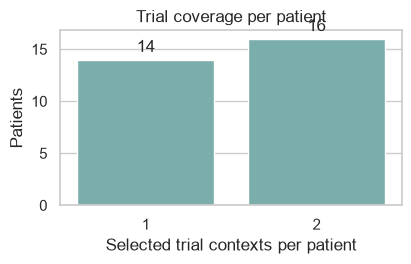

In [28]:
patient_trial_counts = evaluation_df.groupby("patient_id")["trial_id"].nunique().reset_index(name="trial_contexts")
trial_count_distribution = patient_trial_counts["trial_contexts"].value_counts().sort_index().reset_index()
trial_count_distribution.columns = ["trial_contexts", "patients"]

fig, ax = plt.subplots(figsize=(4.4, 2.8))
sns.barplot(data=trial_count_distribution, x="trial_contexts", y="patients", color="#72B7B2", ax=ax)
ax.bar_label(ax.containers[0], padding=3)
ax.set(xlabel="Selected trial contexts per patient", ylabel="Patients", title="Trial coverage per patient")
plt.tight_layout()
plt.show()

#### Prepare published TrialGPT GPT-4 baseline labels

In [29]:
evaluation_df["baseline_label"] = evaluation_df.apply(
    lambda row: label_map.get((row["criterion_type"], row["gpt4_eligibility"])), axis=1
)

assert evaluation_df["baseline_label"].notna().all(), "Unmapped baseline labels found"
evaluation_df["baseline_agrees"] = evaluation_df["baseline_label"].eq(evaluation_df["ground_truth_label"])

#### Published TrialGPT GPT-4 baseline agreement

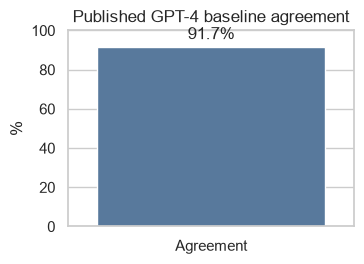

In [30]:
baseline_accuracy = evaluation_df["baseline_agrees"].mean() * 100

fig, ax = plt.subplots(figsize=(3.8, 2.8))
sns.barplot(x=["Agreement"], y=[baseline_accuracy], color="#4C78A8", ax=ax)
ax.bar_label(ax.containers[0], labels=[f"{baseline_accuracy:.1f}%"], padding=3)
ax.set(ylim=(0, 100), xlabel="", ylabel="%", title="Published GPT-4 baseline agreement")
plt.tight_layout()
plt.show()

#### Unsafe MET rate in published TrialGPT GPT-4 baseline

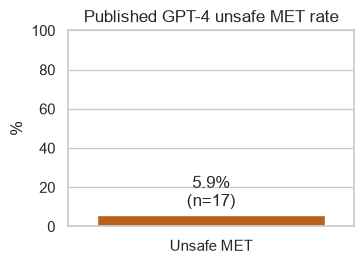

In [31]:
not_met_cases = evaluation_df[evaluation_df["ground_truth_label"].eq("NOT_MET")]
unsafe_met_rate = not_met_cases["baseline_label"].eq("MET").mean() * 100

fig, ax = plt.subplots(figsize=(3.8, 2.8))
sns.barplot(x=["Unsafe MET"], y=[unsafe_met_rate], color="#D55E00", ax=ax)
ax.bar_label(ax.containers[0], labels=[f"{unsafe_met_rate:.1f}%\n(n={len(not_met_cases)})"], padding=3)
ax.set(ylim=(0, 100), xlabel="", ylabel="%", title="Published GPT-4 unsafe MET rate")
plt.tight_layout()
plt.show()

#### UNKNOWN recall in published TrialGPT GPT-4 baseline

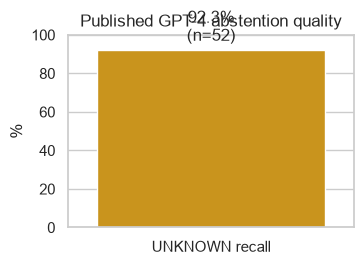

In [32]:
unknown_cases = evaluation_df[evaluation_df["ground_truth_label"].eq("UNKNOWN")]
unknown_recall = unknown_cases["baseline_label"].eq("UNKNOWN").mean() * 100

fig, ax = plt.subplots(figsize=(3.8, 2.8))
sns.barplot(x=["UNKNOWN recall"], y=[unknown_recall], color="#E69F00", ax=ax)
ax.bar_label(ax.containers[0], labels=[f"{unknown_recall:.1f}%\n(n={len(unknown_cases)})"], padding=3)
ax.set(ylim=(0, 100), xlabel="", ylabel="%", title="Published GPT-4 abstention quality")
plt.tight_layout()
plt.show()

#### Published TrialGPT GPT-4 explanation-quality distribution

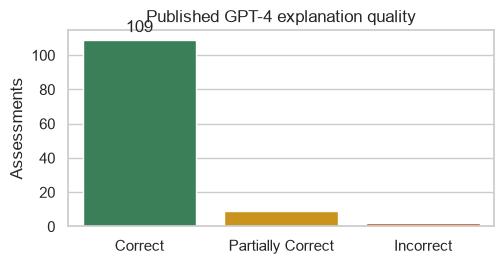

In [33]:
quality_order = ["Correct", "Partially Correct", "Incorrect"]
quality_counts = evaluation_df["explanation_correctness"].value_counts().reindex(quality_order).fillna(0).reset_index()
quality_counts.columns = ["explanation_correctness", "count"]

fig, ax = plt.subplots(figsize=(5.2, 2.8))
sns.barplot(data=quality_counts, x="explanation_correctness", y="count", hue="explanation_correctness",
            palette={"Correct": "#2E8B57", "Partially Correct": "#E69F00", "Incorrect": "#D55E00"},
            legend=False, ax=ax)
ax.bar_label(ax.containers[0], padding=3)
ax.set(xlabel="", ylabel="Assessments", title="Published GPT-4 explanation quality")
plt.tight_layout()
plt.show()

#### Cohort overview table

In [34]:
cohort_overview = pd.DataFrame({
    "metric": ["Synthetic patients", "Candidate trials", "Selected criteria", "Patient–trial contexts", "Inclusion assessments", "Exclusion assessments"],
    "value": [
        patients_df["patient_id"].nunique(),
        criteria_df["trial_id"].nunique(),
        criteria_df["criterion_id"].nunique(),
        evaluation_df[["patient_id", "trial_id"]].drop_duplicates().shape[0],
        (evaluation_df["criterion_type"] == "inclusion").sum(),
        (evaluation_df["criterion_type"] == "exclusion").sum()
    ]
})

display(cohort_overview)

,metric,value
0,Synthetic patients,30
1,Candidate trials,46
2,Selected criteria,120
3,Patient–trial contexts,46
4,Inclusion assessments,79
5,Exclusion assessments,41


#### Small cohort-at-a-glance cards

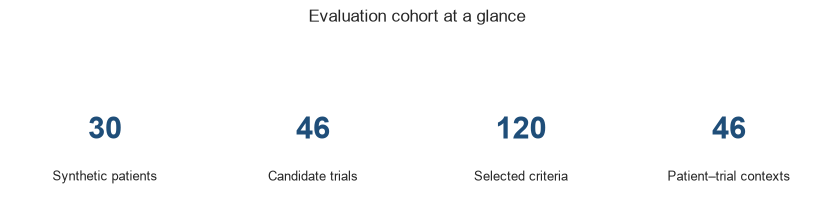

In [35]:
card_data = cohort_overview.iloc[:4]

fig, axes = plt.subplots(1, 4, figsize=(8.5, 2.1))
for ax, (_, row) in zip(axes, card_data.iterrows()):
    ax.text(0.5, 0.58, f"{row['value']}", ha="center", va="center", fontsize=22, fontweight="bold", color="#1F4E79")
    ax.text(0.5, 0.25, row["metric"], ha="center", va="center", fontsize=9, wrap=True)
    ax.set_axis_off()
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#D9E2F3")

fig.suptitle("Evaluation cohort at a glance", y=1.05, fontsize=12)
plt.tight_layout()
plt.show()

#### Trial and criterion overview table

In [36]:
trial_overview = criteria_df.groupby(["trial_id", "trial_title"]).agg(
    selected_criteria=("criterion_id", "nunique"),
    inclusion_criteria=("criterion_type", lambda x: (x == "inclusion").sum()),
    exclusion_criteria=("criterion_type", lambda x: (x == "exclusion").sum())
).reset_index().sort_values(["selected_criteria", "trial_id"], ascending=[False, True])

display(trial_overview)

,trial_id,trial_title,selected_criteria,inclusion_criteria,exclusion_criteria
5,NCT00182832,e-CHAMP: Enhancing Care for Hospitalized Older Adults With Memory Problems,4,3,1
9,NCT00373048,Mefloquine Prophylaxis in HIV-1 Individuals: a Randomized Placebo-controlled Trial,4,3,1
17,NCT00997100,Exploratory Study of Changes in Disease Activity and Biomarkers With ABR-215757 in Patients With Mild Active Systemic Lupus Erythematosus (SLE),4,2,2
20,NCT01255670,Penicillin and Metronidazole in Treatment of Peritonsillar Abscess,4,4,0
21,NCT01260883,Ketorolac in Postoperative Infants: Pharmacokinetics and Safety,4,1,3
22,NCT01308112,Prenatal Iron and Malaria Study,4,2,2
23,NCT01326507,Prognostic Value of Heart-type Fatty Acid-Binding Protein (h-FABP) in Acute Pulmonary Embolism,4,1,3
28,NCT01745731,Cell Infusion Intraportal Autologous Bone Marrow Mononuclear as Enhancer of Liver Regeneration,4,4,0
32,NCT02097186,Preconditioning Shields Against Vascular Events in Surgery,4,2,2
34,NCT02238756,Safety and Tolerability of CV8102 Alone and in Combination With a Rabies Virus Vaccine in Healthy Adults,4,3,1


#### Criteria explorer preview

In [37]:
criteria_explorer = criteria_df.sort_values(["trial_id", "criterion_type", "criterion_id"])
display(criteria_explorer[["criterion_id", "trial_id", "trial_title", "criterion_type", "criterion_text"]])

,criterion_id,trial_id,trial_title,criterion_type,criterion_text
58,CRIT_059,NCT00015626,A Clinical Trial to Prevent the Complications of Insulin Resistance (Including Type-2 Diabetes),exclusion,History of poor compliance with physician's recommendations
90,CRIT_091,NCT00034437,Immune Response to Cytomegalovirus,exclusion,Diagnosis or suspicion of immunodeficiency state
104,CRIT_105,NCT00084240,"Azithromycin Plus Chloroquine Versus Sulfadoxine-Pyrimethamine Plus Chloroquine For The Treatment Of Uncomplicated, Symptomatic Falciparum Malaria In Southe...",exclusion,"History of allergy to or hypersensitivity to azithromycin or any macrolide, sulfonamides, pyrimethamine, or chloroquine"
105,CRIT_106,NCT00084240,"Azithromycin Plus Chloroquine Versus Sulfadoxine-Pyrimethamine Plus Chloroquine For The Treatment Of Uncomplicated, Symptomatic Falciparum Malaria In Southe...",inclusion,"Females and males >=18 years of age with uncomplicated, symptomatic malaria as indicated by the presence of both of the following: a.) Blood smears positive..."
107,CRIT_108,NCT00084240,"Azithromycin Plus Chloroquine Versus Sulfadoxine-Pyrimethamine Plus Chloroquine For The Treatment Of Uncomplicated, Symptomatic Falciparum Malaria In Southe...",inclusion,Women of childbearing potential must have a negative urine gonadotropin prior to entry into the study and must agree to use adequate contraception during th...
...,...,...,...,...,...
118,CRIT_119,NCT02562040,Pediatric Adenotonsillectomy Trial for Snoring,inclusion,Centrally-scored polysomnogram (PSG) confirming an obstructive apnea index (OAI) <1/hour and apnea-hypopnea index (AHI) ≤3/hour and no oxygen saturation (Sp...
33,CRIT_034,NCT02618655,Clinical Research for the Diagnosis of Tick-borne Diseases in Patients With Unexplained Acute Fever,exclusion,we find that the patient selected does not meet the selection criteria within the observation period
32,CRIT_033,NCT02618655,Clinical Research for the Diagnosis of Tick-borne Diseases in Patients With Unexplained Acute Fever,inclusion,temperature is higher than 38℃ Celsius degree
34,CRIT_035,NCT02618655,Clinical Research for the Diagnosis of Tick-borne Diseases in Patients With Unexplained Acute Fever,inclusion,patients have fever more than one week


#### Why review is needed

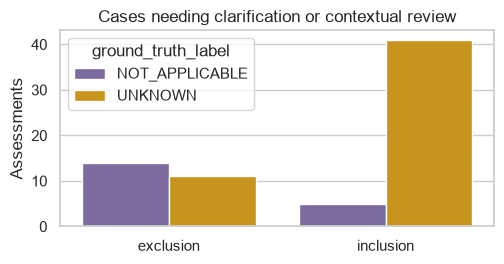

In [38]:
review_reasons = evaluation_df[evaluation_df["ground_truth_label"].isin(["UNKNOWN", "NOT_APPLICABLE"])].groupby(
    ["criterion_type", "ground_truth_label"]
).size().reset_index(name="count")

fig, ax = plt.subplots(figsize=(5.2, 2.8))
sns.barplot(data=review_reasons, x="criterion_type", y="count", hue="ground_truth_label",
            palette={"UNKNOWN": "#E69F00", "NOT_APPLICABLE": "#7B61A8"}, ax=ax)
ax.set(xlabel="", ylabel="Assessments", title="Cases needing clarification or contextual review")
plt.tight_layout()
plt.show()

In [42]:
baseline_dashboard_df = ground_truth_df.merge(
    criteria_df, on=["criterion_id", "trial_id", "criterion_type"], how="left"
)

baseline_dashboard_df["baseline_label"] = baseline_dashboard_df.apply(
    lambda row: label_map.get((row["criterion_type"], row["gpt4_eligibility"])), axis=1
)
baseline_dashboard_df["baseline_agrees"] = baseline_dashboard_df["baseline_label"].eq(baseline_dashboard_df["ground_truth_label"])
baseline_dashboard_df["patient_trial_context"] = baseline_dashboard_df["patient_id"] + " | " + baseline_dashboard_df["trial_id"]
baseline_dashboard_df["reference_review_flag"] = baseline_dashboard_df["ground_truth_label"].isin(["UNKNOWN", "NOT_APPLICABLE"]).astype(int)
baseline_dashboard_df["baseline_agreement_flag"] = baseline_dashboard_df["baseline_agrees"].astype(int)
baseline_dashboard_df["baseline_unsafe_met_flag"] = (
    (baseline_dashboard_df["ground_truth_label"] == "NOT_MET") &
    (baseline_dashboard_df["baseline_label"] == "MET")
).astype(int)
baseline_dashboard_df["baseline_correct_unknown_flag"] = (
    (baseline_dashboard_df["ground_truth_label"] == "UNKNOWN") &
    (baseline_dashboard_df["baseline_label"] == "UNKNOWN")
).astype(int)

assert len(baseline_dashboard_df) == 120
assert baseline_dashboard_df["criterion_text"].notna().all()
assert baseline_dashboard_df["baseline_label"].notna().all()

baseline_dashboard_df.to_csv(processed_dir / "dashboard_baseline.csv", index=False)
print((processed_dir / "dashboard_baseline.csv").resolve())

/Users/nevena/Ironhack_Labs/week9/Clinical-trial-eligibility-copilot/data/processed/dashboard_baseline.csv


In [43]:
import os
from pathlib import Path
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv(Path("../.env"))
assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY is missing from ../.env"
client = OpenAI()
print("OpenAI client ready.")

OpenAI client ready.


#### selects an UNKNOWN case
##### abstaining and routing to review is an important safety behaviour

In [44]:
test_case = baseline_dashboard_df.loc[
    baseline_dashboard_df["ground_truth_label"].eq("UNKNOWN")
].sample(n=1, random_state=42).iloc[0]

display(test_case[[
    "source_annotation_id", "patient_id", "trial_id", "trial_title",
    "criterion_id", "criterion_type", "criterion_text",
    "ground_truth_label", "expert_evidence_sentence_ids"
]].to_frame().T)

,source_annotation_id,patient_id,trial_id,trial_title,criterion_id,criterion_type,criterion_text,ground_truth_label,expert_evidence_sentence_ids
41,463,sigir-201425,NCT00282269,Hypothermia in Traumatic Brain Injury in Children (HiTBIC),CRIT_042,exclusion,are not randomized by 6 hours after injury,UNKNOWN,[]


#### identify one clear MET and one clear NOT_MET case

In [45]:
test_candidates = baseline_dashboard_df.merge(
    patients_df, on="patient_id", how="left"
).copy()

test_candidates = test_candidates.loc[
    test_candidates["ground_truth_label"].isin(["MET", "NOT_MET"])
    & test_candidates["expert_evidence_sentence_ids"].notna()
    & ~test_candidates["expert_evidence_sentence_ids"].eq("[]")
].copy()

test_candidates["note_preview"] = test_candidates["patient_summary"].str.replace("\n", " ", regex=False).str.slice(0, 350) + "..."

for label in ["MET", "NOT_MET"]:
    print(f"\n{label} candidates")
    display(
        test_candidates.loc[test_candidates["ground_truth_label"].eq(label), [
            "source_annotation_id", "patient_id", "trial_id", "criterion_id",
            "criterion_type", "criterion_text", "ground_truth_label",
            "expert_evidence_sentence_ids", "note_preview"
        ]].sort_values(["criterion_text", "source_annotation_id"]).head(8)
    )


MET candidates


,source_annotation_id,patient_id,trial_id,criterion_id,criterion_type,criterion_text,ground_truth_label,expert_evidence_sentence_ids,note_preview
92,887,sigir-201520,NCT00182832,CRIT_093,inclusion,65 years of age or older,MET,[0],0. An 89-year-old man was brought to the emergency department by his wife and son after six months of progressive changes in cognition and personality. 1. H...
36,381,sigir-201421,NCT00997100,CRIT_037,inclusion,Age > 18 years at the time of signing the informed consent form,MET,[0],"0. A 21-year-old female is evaluated for progressive arthralgias and malaise. 1. On examination she is found to have alopecia, a rash mainly distributed on ..."
4,159,sigir-201410,NCT02097186,CRIT_005,inclusion,Age greater than 18 years,MET,[0],0. A physician is called to see a 67-year-old woman who underwent cardiac catheterization via the right femoral artery earlier in the morning. 1. She is now...
68,570,sigir-20151,NCT01142245,CRIT_069,inclusion,Age ≥ 18,MET,[0],"0. A 44 yo male is brought to the emergency room after multiple bouts of vomiting that has a ""coffee ground"" appearance. 1. His heart rate is 135 bpm and bl..."
100,929,sigir-201522,NCT02534727,CRIT_101,inclusion,At least 18 years of age,MET,[0],0. A 65-year-old male with a history of tuberculosis has started to complain of productive cough with tinges of blood. 1. Chest X-ray reveals a round opaque...
16,274,sigir-201416,NCT02238756,CRIT_017,inclusion,Compliant with protocol procedures and available for clinical F/U until the protocol-defined end of the trial,MET,[4],0. A 28-year-old female with neck and shoulder pain and left hand and arm paresthesias three weeks after returning from a trip to California where she atten...
48,519,sigir-201429,NCT01978834,CRIT_049,inclusion,Female sex,MET,[0],0. A 51-year-old woman is seen in clinic for advice on osteoporosis. 1. She has a past medical history of significant hypertension and diet-controlled diabe...
88,599,sigir-20152,NCT02532452,CRIT_089,inclusion,Immunocompromised patient with evidence of viral infection or reactivation,MET,"[1, 3]","0. A 62 yo male presents with four days of non-productive cough and one day of fever. 1. He is on immunosuppressive medications, including prednisone. 2. He..."



NOT_MET candidates


,source_annotation_id,patient_id,trial_id,criterion_id,criterion_type,criterion_text,ground_truth_label,expert_evidence_sentence_ids,note_preview
14,263,sigir-201415,NCT00180739,CRIT_015,exclusion,13. Evidence of uterine pathology other than leiomyoma,NOT_MET,[5],"0. A 36-year-old woman presents to the emergency department with 12 weeks of amenorrhea, vaginal spotting that has increased since yesterday, lower abdomina..."
18,284,sigir-201416,NCT02238756,CRIT_019,exclusion,Acute disease at the time of enrolment. Acute disease is defined as the presence of any acute condition including but not limited to non-febrile or febrile ...,NOT_MET,[3],0. A 28-year-old female with neck and shoulder pain and left hand and arm paresthesias three weeks after returning from a trip to California where she atten...
98,919,sigir-201521,NCT01959048,CRIT_099,inclusion,Confirmed diagnosis of severe CDAD as defined above,NOT_MET,"[0, 1, 4]","0. A 32-year-old male presents to your office complaining of diarrhea, abdominal cramping and flatulence. 1. Stools are greasy and foul-smelling. 2. He also..."
62,135,sigir-20147,NCT01863628,CRIT_063,exclusion,DSM-IV defined Axis I disorders,NOT_MET,[0],0. A 26-year-old obese woman with a history of bipolar disorder complains that her recent struggles with her weight and eating have caused her to feel depre...
90,616,sigir-20152,NCT00034437,CRIT_091,exclusion,Diagnosis or suspicion of immunodeficiency state,NOT_MET,[1],"0. A 62 yo male presents with four days of non-productive cough and one day of fever. 1. He is on immunosuppressive medications, including prednisone. 2. He..."
86,836,sigir-201516,NCT00839124,CRIT_087,inclusion,"History of episodic wheezing, chest tightness, or shortness of breath after age of 6 years consistent with asthma, or physician diagnosed asthma after age o...",NOT_MET,"[0, 1]","0. A 4 year old boy presents to the emergency room with wheezing. 1. He has had a history of allergic rhinitis, but no history of wheezing. 2. His mother re..."
58,124,sigir-20146,NCT00015626,CRIT_059,exclusion,History of poor compliance with physician's recommendations,NOT_MET,[1],0. 64-year-old obese female with diagnosis of diabetes mellitus and persistently elevated HbA1c. 1. She is reluctant to see a nutritionist and is not compli...
46,489,sigir-201426,NCT00373048,CRIT_047,exclusion,Intent to move out of the study catchment area during the study period,NOT_MET,[0],0. A group of 14 humanitarian service workers is preparing a trip to the Amazon Rainforest region in Brazil. 1. All the members of the group have traveled o...


#### inspect five outputs in the notebook before running all 120

In [46]:
smoke_df = pd.read_csv("../data/processed/llm_predictions_smoke.csv")
smoke_df["agrees_with_reference"] = smoke_df["predicted_label"].eq(smoke_df["ground_truth_label"])

display(smoke_df[[
    "source_annotation_id", "criterion_type", "criterion_text",
    "ground_truth_label", "predicted_label", "evidence_sentence_ids",
    "rationale", "agrees_with_reference", "latency_seconds"
]])

print(f"Successful runs: {smoke_df['status'].eq('success').sum()}/{len(smoke_df)}")
print(f"Agreement: {smoke_df['agrees_with_reference'].mean():.1%}")

,source_annotation_id,criterion_type,criterion_text,ground_truth_label,predicted_label,evidence_sentence_ids,rationale,agrees_with_reference,latency_seconds
0,0,inclusion,Patients of chronic stable angina with abnormal Exercise Myocardial Perfusion Spect Scan with reversible and partially reversible ischemic changes.,UNKNOWN,NOT_MET,"[0, 1, 3, 7]","The patient presents with episodic chest pain but has not been diagnosed with chronic stable angina, and there is no mention of an Exercise Myocardial Perfu...",False,1.62
1,1,inclusion,Male and female,MET,MET,[0],"The patient is a 58-year-old woman, which meets the inclusion criterion for both male and female.",True,1.07
2,8,exclusion,Unstable angina,UNKNOWN,NOT_MET,"[0, 1, 2]","The patient presents with episodic chest pain that is new and accompanied by symptoms such as nausea and dyspnea, which are indicative of unstable angina. T...",False,1.21
3,24,exclusion,"Patients with IHD within 6 months after percutaneous coronary intervention(PCI), and who are stable but are going to implement PCI or coronary artery bypass...",NOT_APPLICABLE,MET,"[3, 4]","The patient has no documented history of ischemic heart disease (IHD) or recent percutaneous coronary intervention (PCI) within the last 6 months, as she de...",False,1.09
4,31,inclusion,patients have fever more than one week,NOT_MET,NOT_MET,[0],"The patient has a fever for only 2 days, which does not meet the criterion of having a fever for more than one week.",True,1.22


Successful runs: 5/5
Agreement: 40.0%


##### refined prompt

In [47]:
smoke_df_v2 = pd.read_csv("../data/processed/llm_predictions_smoke_v2.csv")
smoke_df_v2["agrees_with_reference"] = smoke_df_v2["predicted_label"].eq(smoke_df_v2["ground_truth_label"])

display(smoke_df_v2[[
    "source_annotation_id", "criterion_type", "criterion_text",
    "ground_truth_label", "predicted_label", "evidence_sentence_ids",
    "rationale", "agrees_with_reference", "latency_seconds"
]])

print(f"Agreement: {smoke_df_v2['agrees_with_reference'].mean():.1%}")

,source_annotation_id,criterion_type,criterion_text,ground_truth_label,predicted_label,evidence_sentence_ids,rationale,agrees_with_reference,latency_seconds
0,0,inclusion,Patients of chronic stable angina with abnormal Exercise Myocardial Perfusion Spect Scan with reversible and partially reversible ischemic changes.,UNKNOWN,UNKNOWN,[],The patient summary does not provide information regarding the results of an Exercise Myocardial Perfusion Spect Scan or any indication of chronic stable an...,True,1.93
1,1,inclusion,Male and female,MET,MET,[0],"The patient is a 58-year-old woman, which meets the inclusion criterion for both male and female.",True,0.97
2,8,exclusion,Unstable angina,UNKNOWN,NOT_MET,"[0, 1]","The patient presents with episodic chest pain that is described as pressing/burning and is accompanied by nausea, diaphoresis, and mild dyspnea, which are i...",False,1.14
3,24,exclusion,"Patients with IHD within 6 months after percutaneous coronary intervention(PCI), and who are stable but are going to implement PCI or coronary artery bypass...",NOT_APPLICABLE,MET,"[3, 4]",The patient summary does not mention any history of ischemic heart disease (IHD) or recent percutaneous coronary intervention (PCI) or coronary artery bypas...,False,1.31
4,31,inclusion,patients have fever more than one week,NOT_MET,NOT_MET,[0],"The patient has a fever for only 2 days, which does not meet the criterion of having a fever for more than one week.",True,1.00


Agreement: 60.0%


#### inspect the 33 disagreements

In [48]:
results = pd.read_csv("../data/processed/llm_assessment_results.csv")

disagreements = results[results["agreement_flag"] == 0].copy()
print(f"Disagreements: {len(disagreements)}")

display(disagreements[[
    "source_annotation_id", "patient_id", "trial_id", "criterion_id", "criterion_type",
    "criterion_text", "ground_truth_label", "predicted_label", "rationale",
    "evidence_sentence_ids", "latency_seconds"
]].sort_values(["ground_truth_label", "predicted_label", "criterion_type"]))

Disagreements: 33


,source_annotation_id,patient_id,trial_id,criterion_id,criterion_type,criterion_text,ground_truth_label,predicted_label,rationale,evidence_sentence_ids,latency_seconds
26,212,sigir-201413,NCT02264769,CRIT_010,exclusion,Refusal to give written informed consent.,MET,NOT_MET,"Sentence 6 explicitly states that the patient will provide informed consent, indicating that she does not refuse to give written informed consent. Therefore...",[6],0.78
18,145,sigir-20148,NCT01519271,CRIT_065,exclusion,Active suicide ideation.,MET,UNKNOWN,"There is no information in the patient summary regarding the presence or absence of active suicide ideation. Therefore, it cannot be determined whether this...",[],0.88
27,213,sigir-201413,NCT02264769,CRIT_012,exclusion,Allergy or hypersensitivity to carbetocin or oxytocin.,MET,UNKNOWN,There is no information in the patient summary regarding any allergy or hypersensitivity to carbetocin or oxytocin. Absence of such documentation means the ...,[],1.06
29,236,sigir-201415,NCT00277680,CRIT_013,exclusion,Malignancy,MET,UNKNOWN,There is no explicit documentation of a diagnosis of malignancy or the absence of malignancy in the patient summary. The differential diagnosis includes ves...,[],1.12
41,328,sigir-201418,NCT01260883,CRIT_025,exclusion,Bleeding history in infant or family,MET,UNKNOWN,There is no information in the patient summary regarding a history of bleeding in the infant or the family. The presence of RBCs in the urine (hematuria) do...,[],0.89
66,543,sigir-201430,NCT02273232,CRIT_053,exclusion,Known upper limb PVD,MET,UNKNOWN,There is no explicit mention of upper limb peripheral vascular disease (PVD) in the patient summary. The summary discusses symptoms and findings related to ...,[],0.95
97,829,sigir-201516,NCT00930826,CRIT_085,exclusion,Steroid inhalation or ingestion,MET,UNKNOWN,There is no information in the patient summary regarding the use of steroid inhalation or ingestion. The summary does not mention any current or past use of...,[],0.80
114,964,sigir-201523,NCT00084240,CRIT_105,exclusion,"History of allergy to or hypersensitivity to azithromycin or any macrolide, sulfonamides, pyrimethamine, or chloroquine",MET,UNKNOWN,"There is no information in the patient summary regarding any history of allergy or hypersensitivity to azithromycin, macrolides, sulfonamides, pyrimethamine...",[],1.04
71,595,sigir-20151,NCT00843063,CRIT_072,exclusion,"pregnancy, lactation, child-bearing potential in the absence of contraception",NOT_APPLICABLE,MET,"The patient is a 44-year-old male, which excludes the possibility of pregnancy, lactation, or child-bearing potential. Therefore, this exclusion criterion i...",[0],0.96
107,920,sigir-201521,NCT01959048,CRIT_100,exclusion,Pregnant or lactating women,NOT_APPLICABLE,MET,"The patient is described as a 32-year-old male, so he cannot be pregnant or lactating. Therefore, the exclusion criterion is not triggered.",[0],0.74


In [49]:
unsafe_met_cases = results[results["unsafe_met_flag"] == 1].copy()

display(unsafe_met_cases[[
    "source_annotation_id", "patient_id", "trial_id", "trial_title", "criterion_id",
    "criterion_type", "criterion_text", "ground_truth_label", "predicted_label",
    "rationale", "evidence_sentence_ids"
]])

,source_annotation_id,patient_id,trial_id,trial_title,criterion_id,criterion_type,criterion_text,ground_truth_label,predicted_label,rationale,evidence_sentence_ids
115,977,sigir-201523,NCT02334514,The Effect of Oseltamivir Treatment on the Yield of Polymerase Chain Reaction Test for Confirmed Influenza Infection,CRIT_107,inclusion,"clinical presentation that suggest influenza virus infection, including sudden onset of high fever, cough, headache, muscle and joint pain, severe malaise, ...",NOT_MET,MET,"The patient presents with sudden onset of high fever, severe headache, and joint pain, which are among the symptoms listed in the criterion for clinical pre...",[0]


In [51]:
unsafe_case = unsafe_met_cases.iloc[0]

print("Criterion:", unsafe_case["criterion_text"])
print("\nReference:", unsafe_case["ground_truth_label"])
print("Prediction:", unsafe_case["predicted_label"])
print("\nLLM rationale:", unsafe_case["rationale"])
print("\nPatient note:\n", unsafe_case["patient_note"])

Criterion: clinical presentation that suggest influenza virus infection, including sudden onset of high fever, cough, headache, muscle and joint pain, severe malaise, sore throat and runny nose

Reference: NOT_MET
Prediction: MET

LLM rationale: The patient presents with sudden onset of high fever, severe headache, and joint pain, which are among the symptoms listed in the criterion for clinical presentation suggestive of influenza virus infection.


KeyError: 'patient_note'

In [52]:
patients = pd.read_csv("../data/processed/patients.csv")

unsafe_case_with_note = unsafe_met_cases.merge(
    patients[["patient_id", "patient_summary"]],
    on="patient_id",
    how="left",
    validate="many_to_one"
)

unsafe_case = unsafe_case_with_note.iloc[0]

print("Criterion:", unsafe_case["criterion_text"])
print("\nReference:", unsafe_case["ground_truth_label"])
print("Prediction:", unsafe_case["predicted_label"])
print("\nLLM rationale:", unsafe_case["rationale"])
print("\nPatient note:\n", unsafe_case["patient_summary"])

Criterion: clinical presentation that suggest influenza virus infection, including sudden onset of high fever, cough, headache, muscle and joint pain, severe malaise, sore throat and runny nose

Reference: NOT_MET
Prediction: MET

LLM rationale: The patient presents with sudden onset of high fever, severe headache, and joint pain, which are among the symptoms listed in the criterion for clinical presentation suggestive of influenza virus infection.

Patient note:
 0. An 18-year-old male returning from a recent vacation in Asia presents to the ER with a sudden onset of high fever, chills, facial flushing, epistaxis and severe headache and joint pain.
1. His complete blood count reveals leukopenia, increased hematocrit concentration and thrombocytopenia.
2. The patient will provide informed consent, and will comply with the trial protocol without any practical issues.


In [53]:
error_matrix = pd.crosstab(
    results["ground_truth_label"],
    results["predicted_label"],
    margins=True
)

display(error_matrix)

error_patterns = (
    results[results["agreement_flag"] == 0]
    .groupby(["ground_truth_label", "predicted_label", "criterion_type"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(error_patterns)

predicted_label,MET,NOT_APPLICABLE,NOT_MET,UNKNOWN,All
ground_truth_label,,,,,
MET,24,0,1,7,32
NOT_APPLICABLE,3,3,4,9,19
NOT_MET,1,0,12,4,17
UNKNOWN,1,0,3,48,52
All,29,3,20,68,120


,ground_truth_label,predicted_label,criterion_type,count
1,MET,UNKNOWN,exclusion,7
4,NOT_APPLICABLE,UNKNOWN,exclusion,7
3,NOT_APPLICABLE,NOT_MET,exclusion,4
2,NOT_APPLICABLE,MET,exclusion,3
10,UNKNOWN,NOT_MET,inclusion,3
5,NOT_APPLICABLE,UNKNOWN,inclusion,2
7,NOT_MET,UNKNOWN,exclusion,2
8,NOT_MET,UNKNOWN,inclusion,2
0,MET,NOT_MET,exclusion,1
6,NOT_MET,MET,inclusion,1


In [54]:
from pathlib import Path

output_dir = Path("../data/processed")

error_matrix_export = error_matrix.reset_index()
error_matrix_export.to_csv(output_dir / "error_confusion_matrix.csv", index=False)
error_patterns.to_csv(output_dir / "error_patterns.csv", index=False)

markdown_tables = f"""## Error-pattern tables

### Confusion matrix

{error_matrix_export.to_markdown(index=False)}

### Disagreement patterns by criterion type

{error_patterns.to_markdown(index=False)}
"""

print(markdown_tables)

## Error-pattern tables

### Confusion matrix

| ground_truth_label   |   MET |   NOT_APPLICABLE |   NOT_MET |   UNKNOWN |   All |
|:---------------------|------:|-----------------:|----------:|----------:|------:|
| MET                  |    24 |                0 |         1 |         7 |    32 |
| NOT_APPLICABLE       |     3 |                3 |         4 |         9 |    19 |
| NOT_MET              |     1 |                0 |        12 |         4 |    17 |
| UNKNOWN              |     1 |                0 |         3 |        48 |    52 |
| All                  |    29 |                3 |        20 |        68 |   120 |

### Disagreement patterns by criterion type

| ground_truth_label   | predicted_label   | criterion_type   |   count |
|:---------------------|:------------------|:-----------------|--------:|
| MET                  | UNKNOWN           | exclusion        |       7 |
| NOT_APPLICABLE       | UNKNOWN           | exclusion        |       7 |
| NOT_APPLICABLE       